# Using the first 5000 images in the MNIST dataset, compare how the number of neurons in the first layer impacts the training and validation accuracy.
## For loop using 1,2,4,8,16,32 in the first layer, 100 epochs, batch_size 128, and RMSProp.

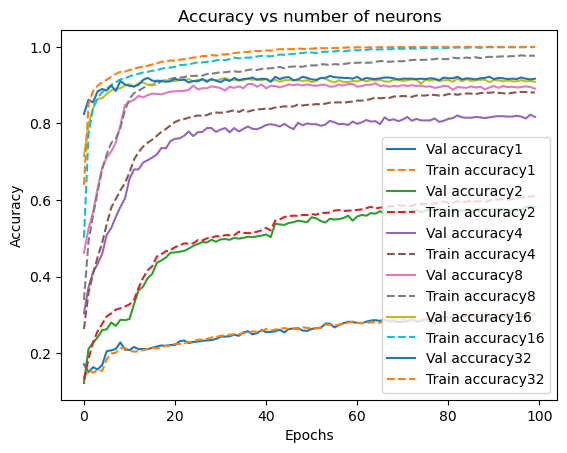

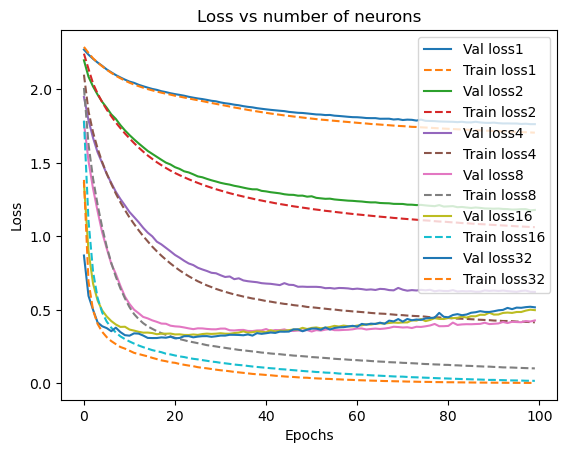

In [22]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
######################################################################
# added this line to speed training (but reduces accuracy due to fewer images)
train_images = train_images[:5000]
train_labels = train_labels[:5000]
##############################################################################
historylist = []

for i in [1,2,4,8,16,32]:
    model = keras.Sequential([
        layers.Dense(i, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    history = model.fit(train_images, train_labels,
              epochs=100,
              batch_size=128,
              validation_split=0.2,
              verbose = 0)
    historylist.append(history.history)

histlistcopy = historylist.copy()

for i in [1,2,4,8,16,32]:
    epochs = np.arange(1,100)
    hist=historylist.pop(0)
    plt.plot(hist['val_accuracy'], "-",
             label="Val accuracy" + str(i))
    plt.plot(hist['accuracy'], "--",
             label="Train accuracy" + str(i))
plt.title("Accuracy vs number of neurons")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

for i in [1,2,4,8,16,32]:
    epochs = np.arange(1,100)
    hist=histlistcopy.pop(0)
    plt.plot(hist['val_loss'], "-",
             label="Val loss" + str(i))
    plt.plot(hist['loss'], "--",
             label="Train loss" + str(i))
plt.title("Loss vs number of neurons")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()